# Chapter 2 — Configuration Space

*Modern Robotics, Lynch & Park*

**Goal of this notebook.** Build visual intuition for the key Chapter 2 ideas — degrees of freedom, Grübler's formula, configuration-space topology, holonomic vs nonholonomic constraints, and workspace — by seeing them move under sliders. Every cell is yours to edit: change parameters, add your own examples, break things.

**How to use.** Read Lynch section-by-section, then run the corresponding cell here and move the sliders until the abstract statement in the book becomes obvious geometrically. The code is deliberately short so the pattern is copyable to later chapters.

## Contents
1. Degrees of freedom of a rigid body (§2.1)
2. Grübler's formula for mechanisms (§2.2)
3. Configuration-space topology — the 2R arm is a torus (§2.3)
4. Holonomic vs nonholonomic — the unicycle (§2.4)
5. Task space vs workspace (§2.5)
6. Your own iteration prompts


## Setup

If this is your first time, run the cell below to install dependencies. Later chapters will pull in `roboticstoolbox-python` and `modern_robotics` more heavily; Chapter 2 only really needs numpy, matplotlib, and ipywidgets.


In [1]:
# Uncomment to install (one-time). Prefer a venv.
# !pip install numpy matplotlib ipywidgets modern_robotics roboticstoolbox-python

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from ipywidgets import interact, FloatSlider, IntSlider
%matplotlib inline

# Lynch's library — not strictly needed for Ch. 2 but import it to confirm install
import modern_robotics as mr
print("modern_robotics version:", mr.__name__, "— ok")


modern_robotics version: modern_robotics — ok


## 1. Degrees of Freedom of a Rigid Body (§2.1)

A rigid body in the plane has **3 DOF**: two for position (x, y) and one for orientation (θ). In 3D space it has **6 DOF**: three translational, three rotational.

Move the sliders below and confirm that every reachable pose of the blue body corresponds to a unique (x, y, θ) triple — and conversely, every triple gives exactly one pose. That bijection is what "3 DOF" means.


In [ ]:
def plot_planar_body(x, y, theta_deg):
    theta = np.radians(theta_deg)
    fig, ax = plt.subplots(figsize=(6, 6))

    # world frame (fixed at origin)
    ax.arrow(0, 0, 0.35, 0, head_width=0.04, color='red', alpha=0.4)
    ax.arrow(0, 0, 0, 0.35, head_width=0.04, color='green', alpha=0.4)
    ax.text(0.4, -0.05, 'world', fontsize=8, color='gray')

    # body (rectangle) rotated to theta
    w, h = 0.4, 0.25
    body = Rectangle((x - w/2, y - h/2), w, h, angle=theta_deg,
                     rotation_point='center', alpha=0.35, color='blue',
                     edgecolor='blue')
    ax.add_patch(body)

    # body frame
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    bx = R @ np.array([0.3, 0])
    by = R @ np.array([0, 0.3])
    ax.arrow(x, y, bx[0], bx[1], head_width=0.04, color='red')
    ax.arrow(x, y, by[0], by[1], head_width=0.04, color='green')

    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.set_title(f'Planar rigid body — 3 DOF\n(x={x:.2f}, y={y:.2f}, θ={theta_deg:.0f}°)')
    plt.show()

interact(plot_planar_body,
         x=FloatSlider(min=-1.2, max=1.2, step=0.05, value=0.4, description='x'),
         y=FloatSlider(min=-1.2, max=1.2, step=0.05, value=0.3, description='y'),
         theta_deg=FloatSlider(min=-180, max=180, step=5, value=30, description='θ (deg)'));


interactive(children=(FloatSlider(value=0.4, description='x', max=1.2, min=-1.2, step=0.05), FloatSlider(value…

## 2. Grübler's Formula (§2.2)

For a mechanism with $N$ links (including ground) and $J$ joints where joint $i$ has $f_i$ degrees of freedom:

$$\text{DOF} = m(N - 1 - J) + \sum_{i=1}^{J} f_i$$

where $m = 3$ for planar mechanisms, $m = 6$ for spatial.

The function below is a calculator. Build intuition by feeding it the classic examples from Lynch §2.2 and confirming the numbers.


In [12]:
def grubler(m, N, J, joint_dofs, name=''):
    '''
    m: 3 (planar) or 6 (spatial)
    N: number of links (include ground link)
    J: number of joints
    joint_dofs: list of f_i, length must equal J
    '''
    assert len(joint_dofs) == J, f'Expected {J} joint DOFs, got {len(joint_dofs)}'
    sum_f = sum(joint_dofs)
    dof = m * (N - 1 - J) + sum_f
    print(f'{name:40s}  DOF = {m}·({N}-1-{J}) + {sum_f} = {dof}')
    return dof

# Worked examples from Lynch §2.2
print('--- planar (m=3) ---')
grubler(m=3, N=4, J=4, joint_dofs=[1]*4, name='4-bar linkage (4R)')
grubler(m=3, N=5, J=5, joint_dofs=[1]*5, name='5-bar linkage (5R)')
grubler(m=3, N=8, J=9, joint_dofs=[1]*9, name='Stephenson six-bar')

print('\n--- spatial (m=6) ---')
# Stewart platform: 2 bodies (top + ground) + 6 legs, each leg is
# Universal(2) + Prismatic(1) + Spherical(3) in series → 3 links per leg
# Total N = 2 + 6·2 = 14 (each leg adds 2 intermediate links)
# J = 18 (3 joints per leg × 6 legs)
grubler(m=6, N=14, J=18, joint_dofs=[2,1,3]*6, name='Stewart platform (6-UPS)')


--- planar (m=3) ---
4-bar linkage (4R)                        DOF = 3·(4-1-4) + 4 = 1
5-bar linkage (5R)                        DOF = 3·(5-1-5) + 5 = 2
Stephenson six-bar                        DOF = 3·(8-1-9) + 9 = 3

--- spatial (m=6) ---
Stewart platform (6-UPS)                  DOF = 6·(14-1-18) + 36 = 6


6

## 3. C-space Topology — the 2R arm is a torus (§2.3)

This is the money idea of Chapter 2. The **dimension** of a 2R arm's C-space is 2 (two joint angles), but its **topology** is not $\mathbb{R}^2$ — it's a torus $T^2 = S^1 \times S^1$, because each angle wraps around.

Two panels below. Move the joint sliders and watch both:
- **Left:** the physical arm in task space.
- **Right:** the current configuration as a red dot in C-space, drawn as a square with opposite edges identified (which is literally the definition of a torus).

Then run the next cell to see the same C-space drawn as an actual torus in 3D.


In [ ]:
def plot_2r_arm(theta1_deg, theta2_deg, L1=1.0, L2=0.8):
    t1 = np.radians(theta1_deg); t2 = np.radians(theta2_deg)
    x1 = L1*np.cos(t1);             y1 = L1*np.sin(t1)
    x2 = x1 + L2*np.cos(t1+t2);     y2 = y1 + L2*np.sin(t1+t2)

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    # LEFT: task space
    ax = axes[0]
    ax.plot([0, x1, x2], [0, y1, y2], 'b-', linewidth=3)
    ax.plot(0, 0, 'ks', markersize=12, label='base')
    ax.plot(x1, y1, 'ko', markersize=8, label='joint 2')
    ax.plot(x2, y2, 'ro', markersize=12, label='end-effector')
    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend(loc='upper right')
    ax.set_title(f'Task space — EE at ({x2:.2f}, {y2:.2f})')

    # RIGHT: C-space as unit square (identifying opposite edges = torus)
    ax = axes[1]
    ax.plot(theta1_deg, theta2_deg, 'ro', markersize=14)
    ax.set_xlim(-180, 180); ax.set_ylim(-180, 180)
    ax.set_xlabel('θ₁ (deg)'); ax.set_ylabel('θ₂ (deg)')
    ax.grid(True, alpha=0.3)
    ax.set_title('C-space: square with edges identified = T²')
    # edge identification hint
    for x in [-180, 180]: ax.axvline(x, color='purple', linestyle='--', alpha=0.5)
    for y in [-180, 180]: ax.axhline(y, color='purple', linestyle='--', alpha=0.5)
    ax.text(0, 170, 'top edge ≡ bottom edge', ha='center', color='purple', fontsize=9)
    ax.text(0, -175, 'left edge ≡ right edge', ha='center', color='purple', fontsize=9)

    plt.tight_layout(); plt.show()

interact(plot_2r_arm,
         theta1_deg=FloatSlider(min=-180, max=180, step=5, value=45,  description='θ₁ (deg)'),
         theta2_deg=FloatSlider(min=-180, max=180, step=5, value=60,  description='θ₂ (deg)'));


interactive(children=(FloatSlider(value=45.0, description='θ₁ (deg)', max=180.0, min=-180.0, step=5.0), FloatS…

In [5]:
def plot_3r_arm(theta1_deg, theta2_deg, theta3_deg, L1=1.0, L2=0.8, L3=0.6):
    # Convert all angles to radians
    t1 = np.radians(theta1_deg)
    t2 = np.radians(theta2_deg)
    t3 = np.radians(theta3_deg)
    
    # Forward Kinematics
    x1 = L1 * np.cos(t1)
    y1 = L1 * np.sin(t1)
    
    x2 = x1 + L2 * np.cos(t1 + t2)
    y2 = y1 + L2 * np.sin(t1 + t2)
    
    x3 = x2 + L3 * np.cos(t1 + t2 + t3)
    y3 = y2 + L3 * np.sin(t1 + t2 + t3)

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    # LEFT: Task space
    ax = axes[0]
    ax.plot([0, x1, x2, x3], [0, y1, y2, y3], 'b-', linewidth=3)
    ax.plot(0, 0, 'ks', markersize=10, label='base')
    ax.plot([x1, x2], [y1, y2], 'ko', markersize=6) # intermediate joints
    ax.plot(x3, y3, 'ro', markersize=12, label='end-effector')
    
    limit = L1 + L2 + L3 + 0.2
    ax.set_xlim(-limit, limit); ax.set_ylim(-limit, limit)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend()
    ax.set_title(f'3R Task Space — EE at ({x3:.2f}, {y3:.2f})')

    # RIGHT: C-space representation (3D plot is better for 3 angles)
    # Using a simple scatter for the 3rd dimension since it's hard to visualize T³
    ax = axes[1]
    ax.scatter(theta1_deg, theta2_deg, c=theta3_deg, cmap='hsv', s=200, edgecolor='k')
    ax.set_xlim(-180, 180); ax.set_ylim(-180, 180)
    ax.set_xlabel('θ₁'); ax.set_ylabel('θ₂')
    ax.set_title(f'C-Space Slice (Color = θ₃: {theta3_deg}°)')
    ax.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

interact(plot_3r_arm,
         theta1_deg=FloatSlider(min=-180, max=180, step=5, value=45, description='θ₁'),
         theta2_deg=FloatSlider(min=-180, max=180, step=5, value=45, description='θ₂'),
         theta3_deg=FloatSlider(min=-180, max=180, step=5, value=45, description='θ₃'));


interactive(children=(FloatSlider(value=45.0, description='θ₁', max=180.0, min=-180.0, step=5.0), FloatSlider(…

In [6]:
# Same C-space, drawn as an actual embedded torus in 3D.
# Moving both sliders traces a path on its surface.

def plot_torus(theta1_deg, theta2_deg, R=2.0, r=0.8):
    t1 = np.radians(theta1_deg); t2 = np.radians(theta2_deg)

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    u = np.linspace(0, 2*np.pi, 60); v = np.linspace(0, 2*np.pi, 60)
    U, V = np.meshgrid(u, v)
    X = (R + r*np.cos(V)) * np.cos(U)
    Y = (R + r*np.cos(V)) * np.sin(U)
    Z = r * np.sin(V)
    ax.plot_surface(X, Y, Z, alpha=0.3, cmap='viridis', edgecolor='none')

    px = (R + r*np.cos(t2)) * np.cos(t1)
    py = (R + r*np.cos(t2)) * np.sin(t1)
    pz = r * np.sin(t2)
    ax.scatter([px], [py], [pz], color='red', s=120)

    ax.set_title('C-space of 2R arm as T² = S¹ × S¹')
    ax.set_box_aspect([1,1,0.5])
    plt.show()

interact(plot_torus,
         theta1_deg=FloatSlider(min=0, max=360, step=5, value=60, description='θ₁'),
         theta2_deg=FloatSlider(min=0, max=360, step=5, value=120, description='θ₂'));


interactive(children=(FloatSlider(value=60.0, description='θ₁', max=360.0, step=5.0), FloatSlider(value=120.0,…

## 4. Holonomic vs Nonholonomic Constraints (§2.4)

A **unicycle** (same kinematics as a car ignoring steering lag) has state $(x, y, \theta) \in \mathbb{R}^2 \times S^1$ — a 3-dim C-space. But at any instant it can only move forward/back and rotate. The sideways-velocity constraint

$$\sin\theta \, \dot{x} - \cos\theta \, \dot{y} = 0$$

cannot be integrated into a constraint purely on $(x, y, \theta)$ — it's **nonholonomic**. The unicycle can *reach* any configuration (so the reachable set is still the full 3-dim space), but it cannot *instantaneously* move in every direction in that space.

The plot below shows trajectories for different (v, ω) inputs. Observe that no single straight-line control can translate the unicycle sideways without rotating.


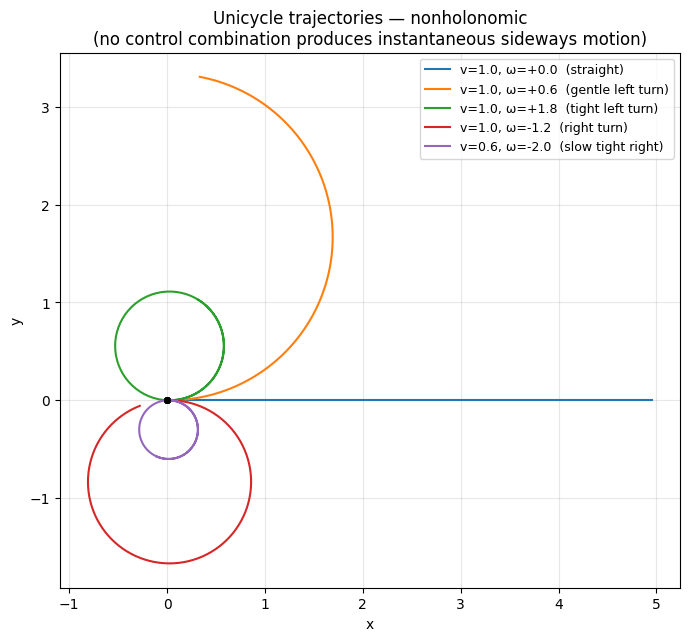

In [7]:
def simulate_unicycle(v, omega, T=5.0, dt=0.05, x0=0, y0=0, th0=0):
    n = int(T/dt)
    x = np.zeros(n); y = np.zeros(n); th = np.zeros(n)
    x[0], y[0], th[0] = x0, y0, th0
    for i in range(1, n):
        x[i]  = x[i-1] + v*np.cos(th[i-1])*dt
        y[i]  = y[i-1] + v*np.sin(th[i-1])*dt
        th[i] = th[i-1] + omega*dt
    return x, y, th

fig, ax = plt.subplots(figsize=(8, 8))
cases = [(1.0,  0.0,  'straight'),
         (1.0,  0.6,  'gentle left turn'),
         (1.0,  1.8,  'tight left turn'),
         (1.0, -1.2,  'right turn'),
         (0.6, -2.0,  'slow tight right')]
for v, w, label in cases:
    x, y, _ = simulate_unicycle(v, w)
    ax.plot(x, y, label=f'v={v}, ω={w:+.1f}  ({label})')
    ax.plot(x[0], y[0], 'ko', markersize=4)

ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
ax.set_title('Unicycle trajectories — nonholonomic\n'
             '(no control combination produces instantaneous sideways motion)')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.show()


**Parallel-parking thought experiment.** To translate the unicycle sideways by 1 m without a net rotation, you have to execute a sequence of forward-turn-back-turn maneuvers. The *reachable* set is full-dimensional; the *instantaneously-reachable* velocity set is a 2D surface in a 3D tangent space. That gap is exactly what nonholonomic means.


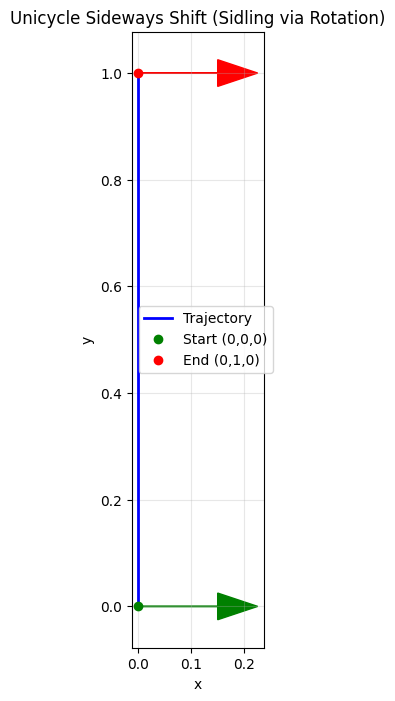

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_unicycle_sequence(inputs, dt=0.05, x0=0, y0=0, th0=0):
    x, y, th = [x0], [y0], [th0]
    
    for v, omega, duration in inputs:
        n_steps = int(duration / dt)
        for _ in range(n_steps):
            # Update using the last state
            new_x = x[-1] + v * np.cos(th[-1]) * dt
            new_y = y[-1] + v * np.sin(th[-1]) * dt
            new_th = th[-1] + omega * dt
            
            x.append(new_x)
            y.append(new_y)
            th.append(new_th)
            
    return np.array(x), np.array(y), np.array(th)

# Sequence: (linear velocity v, angular velocity omega, time duration T)
# 1. Rotate 90 degrees (pi/2 radians)
# 2. Move forward 1 unit
# 3. Rotate back -90 degrees
inputs = [
    (0.0, np.pi/2, 1.0), # Turn left (omega * T = pi/2)
    (1.0, 0.0,     1.0), # Move forward (v * T = 1.0)
    (0.0, -np.pi/2, 1.0) # Turn right (omega * T = -pi/2)
]

x, y, th = simulate_unicycle_sequence(inputs)

# Plotting
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(x, y, 'b-', linewidth=2, label='Trajectory')
ax.plot(x[0], y[0], 'go', label='Start (0,0,0)')
ax.plot(x[-1], y[-1], 'ro', label='End (0,1,0)')

# Draw orientation arrows at start and end
ax.arrow(x[0], y[0], 0.15*np.cos(th[0]), 0.15*np.sin(th[0]), head_width=0.05, color='green')
ax.arrow(x[-1], y[-1], 0.15*np.cos(th[-1]), 0.15*np.sin(th[-1]), head_width=0.05, color='red')

ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title('Unicycle Sideways Shift (Sidling via Rotation)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()
plt.show()


## 5. Task Space vs Workspace (§2.5)

**Task space** is where the task is specified — for a 2R planar arm, that's $\mathbb{R}^2$ (positions of the end-effector). **Workspace** is the subset of task space the robot can actually reach.

For a 2R arm with link lengths $L_1, L_2$, the reachable workspace is the annulus

$$\{(x, y) \mid |L_1 - L_2| \le \sqrt{x^2 + y^2} \le L_1 + L_2\}$$

Sweep the link lengths below and watch the annulus collapse to a disk when $L_1 = L_2$.


In [ ]:
def plot_2r_workspace(L1, L2, n=60):
    th1 = np.linspace(-np.pi, np.pi, n)
    th2 = np.linspace(-np.pi, np.pi, n)
    T1, T2 = np.meshgrid(th1, th2)
    X = L1*np.cos(T1) + L2*np.cos(T1+T2)
    Y = L1*np.sin(T1) + L2*np.sin(T1+T2)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(X.ravel(), Y.ravel(), s=2, alpha=0.3, color='steelblue')

    t = np.linspace(0, 2*np.pi, 200)
    r_out = L1 + L2; r_in = abs(L1 - L2)
    ax.plot(r_out*np.cos(t), r_out*np.sin(t), 'r--', label=f'outer: {r_out:.2f}')
    ax.plot(r_in*np.cos(t),  r_in*np.sin(t),  'r--', label=f'inner: {r_in:.2f}')

    lim = (L1+L2)*1.2
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend()
    ax.set_title(f'Reachable workspace — 2R arm (L₁={L1}, L₂={L2})')
    plt.show()

interact(plot_2r_workspace,
         L1=FloatSlider(min=0.3, max=2.0, step=0.1, value=1.0, description='L₁'),
         L2=FloatSlider(min=0.1, max=2.0, step=0.1, value=0.8, description='L₂'));


interactive(children=(FloatSlider(value=1.0, description='L₁', max=2.0, min=0.3), FloatSlider(value=0.8, descr…

In [10]:
def plot_2r_workspace_obs(L1, L2, obs_x=1.2, obs_y=0.5, obs_r=0.3, n=70):
    th1 = np.linspace(-np.pi, np.pi, n)
    th2 = np.linspace(-np.pi, np.pi, n)
    T1, T2 = np.meshgrid(th1, th2)
    
    # Task space coordinates
    X = L1*np.cos(T1) + L2*np.cos(T1+T2)
    Y = L1*np.sin(T1) + L2*np.sin(T1+T2)

    # Collision Check: Distance from each point to obstacle center
    dist = np.sqrt((X - obs_x)**2 + (Y - obs_y)**2)
    mask = dist > obs_r  # True if the point is OUTSIDE the obstacle

    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Plot valid workspace (mask is True)
    ax.scatter(X[mask], Y[mask], s=2, alpha=0.3, color='steelblue', label='Valid Workspace')
    
    # Optional: Plot blocked workspace in light red to show the "shadow"
    ax.scatter(X[~mask], Y[~mask], s=2, alpha=0.1, color='red')

    # Draw the physical obstacle
    obstacle = plt.Circle((obs_x, obs_y), obs_r, color='orange', alpha=0.7, label='Obstacle', zorder=5)
    ax.add_patch(obstacle)

    # Boundaries
    t = np.linspace(0, 2*np.pi, 200)
    r_out = L1 + L2; r_in = abs(L1 - L2)
    ax.plot(r_out*np.cos(t), r_out*np.sin(t), 'r--', label=f'Reach Limit ({r_out:.1f})')

    lim = (L1+L2)*1.3
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend(loc='upper right')
    ax.set_title('2R Workspace with Circular Obstacle')
    plt.show()

interact(plot_2r_workspace_obs,
         L1=FloatSlider(min=0.3, max=2.0, step=0.1, value=1.0, description='L₁'),
         L2=FloatSlider(min=0.1, max=2.0, step=0.1, value=0.8, description='L₂'),
         obs_x=FloatSlider(min=-2.0, max=2.0, step=0.1, value=1.2, description='Obs X'),
         obs_y=FloatSlider(min=-2.0, max=2.0, step=0.1, value=0.5, description='Obs Y'),
         obs_r=FloatSlider(min=0.05, max=1.0, step=0.05, value=0.3, description='Obs Radius'));


interactive(children=(FloatSlider(value=1.0, description='L₁', max=2.0, min=0.3), FloatSlider(value=0.8, descr…

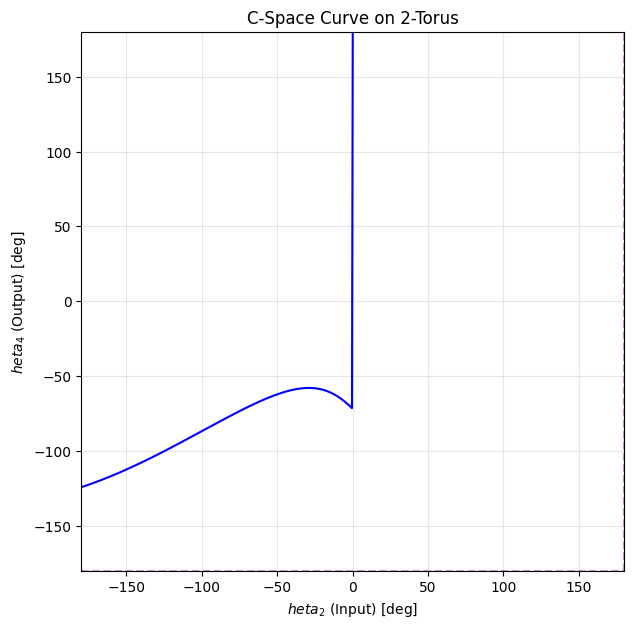

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def get_theta4(theta2, L1, L2, L3, L4):
    # Position of joint A (crank-coupler)
    Ax, Ay = L2 * np.cos(theta2), L2 * np.sin(theta2)
    # Distance from A to ground pivot O4(L1, 0)
    d2 = (Ax - L1)**2 + Ay**2
    d = np.sqrt(d2)
    
    # Check if a triangle exists (Grashof condition)
    if d > L3 + L4 or d < abs(L3 - L4): return None
    
    # Law of Cosines for the interior angle at O4
    cos_gamma = (L4**2 + d2 - L3**2) / (2 * L4 * d)
    gamma = np.arccos(np.clip(cos_gamma, -1, 1))
    
    # Angle of vector O4->A
    alpha = np.arctan2(Ay, Ax - L1)
    
    # Two assembly modes (open and crossed)
    return alpha + gamma, alpha - gamma

# Grashof Crank-Rocker parameters
L1, L2, L3, L4 = 2.0, 1.0, 2.5, 2.0
t2_range = np.linspace(-np.pi, np.pi, 500)
c_curve_open, c_curve_crossed = [], []

for t2 in t2_range:
    res = get_theta4(t2, L1, L2, L3, L4)
    if res:
        c_curve_open.append([np.degrees(t2), np.degrees(res[0])])
        c_curve_crossed.append([np.degrees(t2), np.degrees(res[1])])

# Plotting on the 2-Torus (flattened)
fig, ax = plt.subplots(figsize=(7, 7))
open_pts = np.array(c_curve_open)
ax.plot(open_pts[:,0], open_pts[:,1], 'b-', label='Open Mode')
ax.set_xlim(-180, 180); ax.set_ylim(-180, 180)
ax.set_xlabel('$\theta_2$ (Input) [deg]'); ax.set_ylabel('$\theta_4$ (Output) [deg]')
ax.grid(True, alpha=0.3); ax.set_title('C-Space Curve on 2-Torus')
# Visual markers for torus identification
for val in [-180, 180]:
    ax.axvline(val, color='purple', ls='--', alpha=0.4)
    ax.axhline(val, color='purple', ls='--', alpha=0.4)
plt.show()

## 6. Iteration Prompts

These are the cells you should *modify*, not just run. The point of this notebook is to build your own intuition — pick one or two that feel least obvious from the book and spend 15–20 minutes there.

1. **Add a link.** Extend the 2R arm code to a 3R arm. What does its C-space look like? What's its workspace?
2. **Obstacles.** Add a circular obstacle in task space and shade the corresponding forbidden region of C-space (§2.3.2 C-space obstacles). This is the single most useful exercise in the chapter for motion-planning intuition later.
3. **Nonholonomic planning.** Try to write a sequence of (v, ω) inputs that moves the unicycle from (0, 0, 0) to (0, 1, 0) — i.e., pure sideways shift. Plot the trajectory.
4. **Grübler edge cases.** What does the formula give for an over-constrained mechanism (e.g. two parallel 4-bar linkages)? Compare with actual DOF — where does Grübler's formula lie?
5. **C-space of a 4-bar linkage.** It's a 1-dim curve embedded in a 2-torus. Compute and plot it.

---

## Pattern for subsequent chapters

Each chapter notebook should follow the same skeleton:
1. **Header** — one paragraph on the chapter's core idea.
2. **Setup** — imports (`modern_robotics`, `roboticstoolbox`, `spatialmath` as they become relevant).
3. **One section per major chapter section**, each with:
   - Markdown explaining what the book says.
   - A code cell with an `interact`-wrapped plot so you can move parameters.
4. **Iteration prompts** — modify, don't just run.

For Chapter 3 (rigid-body motions) the natural additions are `spatialmath.SO3` / `SE3` with `.plot()` and `.animate()`, and exponential-coordinate sliders for rotations and twists. For Chapter 5 (wheeled mobile robots), you'll want to connect this to your ROS2/Gazebo work directly.
